📘 Dataset Description

The Smart Irrigation Water Requirement Prediction Dataset aims to optimize water usage in agriculture by predicting the amount of irrigation required under varying environmental conditions.
 Efficient water management is critical for sustainable farming, especially in water-scarce regions.

The dataset includes crop type, soil type, temperature, rainfall, and evapotranspiration parameters, enabling accurate estimation of irrigation needs using machine learning models.
 It supports regression tasks and smart irrigation system development.

🔍 Use Cases

- Smart irrigation systems
- Water resource optimization
- Climate-aware agriculture solutions
- Machine learning regression projects

#### Score: Private 0.96302 / Public 0.96177

#### Place 2197 / 4316

In [18]:
import os

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from imblearn.ensemble import BalancedBaggingClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder

In [19]:
load_dotenv()
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [20]:
output_path = 'data/irrigation-water'
if os.path.exists(output_path):
    print(f"Directory '{output_path}' already exists. Skipping download.")
    path = output_path
else:
    # Download latest version
    path = kagglehub.competition_download('playground-series-s6e4', output_dir=output_path)

    print("Path to competition files:", path)

Directory 'data/irrigation-water' already exists. Skipping download.


In [21]:
test_df = pd.read_csv(os.path.join(path, 'test.zip'))
train_df = pd.read_csv(os.path.join(path, 'train.zip'))
# test_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')
# train_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')

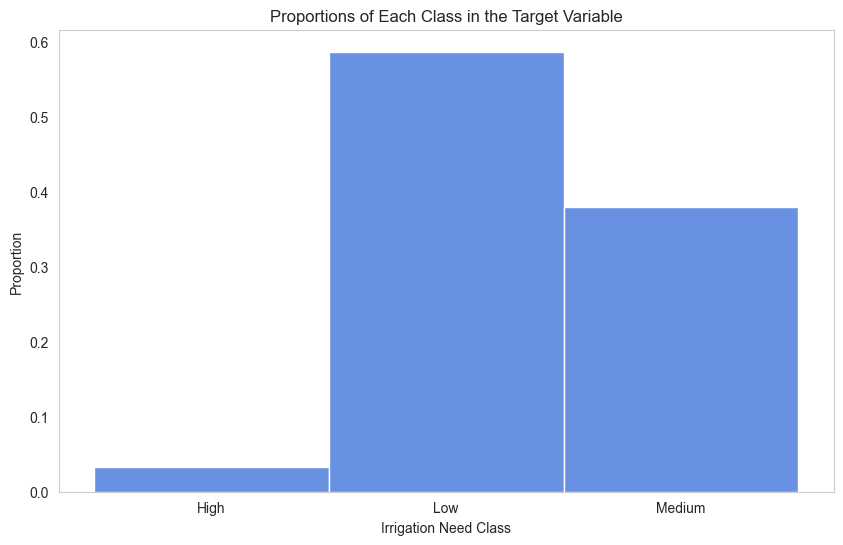

In [22]:
proportions = (train_df['Irrigation_Need'].value_counts() / len(train_df)).sort_index()

sns.histplot(x=proportions.index, weights=proportions.values, bins=len(proportions), kde=False)
plt.title('Proportions of Each Class in the Target Variable')
plt.xlabel('Irrigation Need Class')
plt.ylabel('Proportion')
plt.xticks(proportions.index)
plt.grid()
plt.show()

In [23]:
target_encoder = LabelEncoder() # we need decode after prediction
train_df['Irrigation_Need'] = target_encoder.fit_transform(train_df['Irrigation_Need'])

In [24]:
string_columns = train_df.select_dtypes(include=[str]).columns
print("String columns in the dataset:", string_columns)

String columns in the dataset: Index(['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
       'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region'],
      dtype='str')


In [25]:
# Separate features and target variable
X = train_df.drop('Irrigation_Need', axis=1)
y = train_df['Irrigation_Need']

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.05, random_state=42, stratify=y)
X_train.shape, X_val.shape # check quantity of data after split

((598500, 20), (31500, 20))

In [26]:
one_hot_columns = ['Crop_Type', 'Soil_Type', 'Season', 'Region', 'Water_Source', 'Irrigation_Type']
label_columns = ['Crop_Growth_Stage', 'Mulching_Used']
numerical_columns = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

## Problem of dataset
1. Dataset is imbalanced (0 - 3%, 1- 59%, 2 - 38%). We can use class weights in RandomForestClassifier or try to oversample minority classes with SMOTE.
2. After One-Hot Encoding, we will have 30+ features, which can lead to overfitting. We can try dimensionality reduction techniques like PCA or feature selection based on feature importance.
3. Some features may have low importance for prediction. We can analyze feature importance from the Random Forest model and consider removing less important features to simplify the model and reduce overfitting risk.
4. Seems dataset is more than 1000k rows, so HPO can be time-consuming. We can try to decrease of dataset size with stratified sampling or use a smaller subset for HPO to speed up the process.

# Strategy
1. Create a function make_pipeline with arguments
2. Use this function to create a pipeline and tune it with Optuna
3. Evaluate the model with classification report, confusion matrix, accuracy and balanced accuracy as separate function
4. at the end show visualization of optuna optimization process and feature importance

In [27]:
# Create pipelines for one-hot encoding and label encoding
column_transformer = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), one_hot_columns),
        ('label', OrdinalEncoder(), label_columns),
    ],
    remainder='passthrough'
)

In [28]:
# clf = BalancedRandomForestClassifier(random_state=42) # Score: 0.9623
# clf = EasyEnsembleClassifier(random_state=42, n_jobs=-1) # Score: 0.8785
clf = BalancedBaggingClassifier(random_state=42, n_jobs=-1) # Score: 0.9654

pipeline = ImbPipeline(steps=[
    ('preprocessor', column_transformer),
    ('classifier', clf)
])

pipeline.fit(X_train ,y_train)

y_pred = pipeline.predict(X_val)
balanced_accuracy = balanced_accuracy_score(y_val, y_pred)
print(f'Validation Balanced Accuracy: {balanced_accuracy:.4f}')

Validation Balanced Accuracy: 0.9654


# HPO with Optuna

In [29]:
TARGET_SIZE = 100_000

X_hpo, _, y_hpo, _ = train_test_split(
    X_train,
    y_train,
    train_size=TARGET_SIZE,
    stratify=y_train,
    random_state=42
)

In [35]:
X_processed_values = column_transformer.fit_transform(X_hpo)
columns = column_transformer.get_feature_names_out()
X_processed = pd.DataFrame(X_processed_values, columns=columns)

In [36]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [40]:
from sklearn.tree import DecisionTreeClassifier
from imblearn.ensemble import BalancedBaggingClassifier


def objective(trial):

    # =========================
    # Base estimator params
    # =========================

    max_depth = trial.suggest_int(
        'max_depth',
        3,
        40
    )

    min_samples_split = trial.suggest_int(
        'min_samples_split',
        2,
        50
    )

    min_samples_leaf = trial.suggest_int(
        'min_samples_leaf',
        1,
        20
    )

    criterion = trial.suggest_categorical(
        'criterion',
        ['gini', 'entropy']
    )

    max_features_tree = trial.suggest_categorical(
        'max_features_tree',
        ['sqrt', 'log2', None]
    )

    ccp_alpha = trial.suggest_float(
        'ccp_alpha',
        1e-6,
        1e-2,
        log=True
    )

    estimator = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        max_features=max_features_tree,
        ccp_alpha=ccp_alpha,
        random_state=42
    )

    # =========================
    # Balanced Bagging params
    # =========================

    params = {

        'n_estimators': trial.suggest_int(
            'n_estimators',
            50,
            500
        ),

        'max_samples': trial.suggest_float(
            'max_samples',
            0.3,
            1.0
        ),

        'max_features': trial.suggest_float(
            'max_features',
            0.3,
            1.0
        ),

        'bootstrap': trial.suggest_categorical(
            'bootstrap',
            [True, False]
        ),

        'bootstrap_features': trial.suggest_categorical(
            'bootstrap_features',
            [True, False]
        ),

        'sampling_strategy': trial.suggest_categorical(
            'sampling_strategy',
            [
                'auto',
                'all',
                'not minority',
                'not majority'
            ]
        ),

        'replacement': trial.suggest_categorical(
            'replacement',
            [True, False]
        )
    }

    clf = BalancedBaggingClassifier(
        estimator=estimator,
        **params,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        clf,
        X_processed,
        y_hpo,
        scoring='balanced_accuracy',
        cv=cv,
        n_jobs=-1
    )

    return np.mean(scores)

In [41]:
class EarlyStoppingCallback:

  def __init__(self, patience: int, min_delta: float = 0.0):
      self.patience = patience
      self.min_delta = min_delta
      self.counter = 0
      self.best_value = None

  def __call__(self, study, trial):
      # initialize
      if self.best_value is None:
          self.best_value = study.best_value
          return

      # check improvement by study direction
      if study.direction == optuna.study.StudyDirection.MINIMIZE:
          improved = study.best_value < self.best_value - self.min_delta
      else:  # MAXIMIZE
          improved = study.best_value > self.best_value + self.min_delta

      if improved:
          self.best_value = study.best_value
          self.counter = 0
      else:
          self.counter += 1

      if self.counter >= self.patience:
          study.stop()
          print(f'Early stopping triggered after {self.counter} trials with no improvement.')

In [42]:
# pruner = optuna.pruners.PatientPruner(optuna.pruners.SuccessiveHalvingPruner(), patience=10)
pruner = optuna.pruners.MedianPruner()
es_cb = EarlyStoppingCallback(patience=10, min_delta=0.001)

study = optuna.create_study(
                     direction=optuna.study.StudyDirection.MAXIMIZE,
                     sampler=optuna.samplers.TPESampler(seed=42),
                     storage='sqlite:///optuna_irrigation.db',
                     pruner=pruner)

study.optimize(objective,
               n_trials=100,
               n_jobs=-1,
               show_progress_bar=True,
               callbacks=[es_cb])

[I 2026-05-29 12:09:13,412] A new study created in RDB with name: no-name-80cad442-1f7a-452a-8950-0d287899c166


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-29 12:10:19,432] Trial 2 finished with value: 0.9534906266147751 and parameters: {'max_depth': 33, 'min_samples_split': 28, 'min_samples_leaf': 12, 'criterion': 'gini', 'max_features_tree': None, 'ccp_alpha': 0.002869920373725331, 'n_estimators': 374, 'max_samples': 0.4864120435514133, 'max_features': 0.7481096540534317, 'bootstrap': False, 'bootstrap_features': False, 'sampling_strategy': 'not minority', 'replacement': False}. Best is trial 2 with value: 0.9534906266147751.
[I 2026-05-29 12:10:39,045] Trial 1 finished with value: 0.6745361218897982 and parameters: {'max_depth': 22, 'min_samples_split': 8, 'min_samples_leaf': 14, 'criterion': 'gini', 'max_features_tree': 'sqrt', 'ccp_alpha': 1.1380083621643866e-05, 'n_estimators': 334, 'max_samples': 0.5937500022411184, 'max_features': 0.8439467520126422, 'bootstrap': True, 'bootstrap_features': False, 'sampling_strategy': 'not majority', 'replacement': False}. Best is trial 2 with value: 0.9534906266147751.
[I 2026-05-29 12

In [43]:
best_params = study.best_params

In [44]:
optuna.visualization.plot_optimization_history(study)

In [45]:
optuna.visualization.plot_parallel_coordinate(study)

In [46]:
best_params

{'max_depth': 29,
 'min_samples_split': 45,
 'min_samples_leaf': 11,
 'criterion': 'entropy',
 'max_features_tree': None,
 'ccp_alpha': 5.4845690705441824e-05,
 'n_estimators': 155,
 'max_samples': 0.5414848384250321,
 'max_features': 0.6914711172507041,
 'bootstrap': False,
 'bootstrap_features': False,
 'sampling_strategy': 'all',
 'replacement': False}

In [ ]:
estimator = DecisionTreeClassifier(
    max_depth=7,
    min_samples_split=49,
    min_samples_leaf=10,
    criterion='entropy',
    max_features=None,
    ccp_alpha=0.0007440443555965785,
    random_state=42
)

clf = BalancedBaggingClassifier(
    estimator=estimator,
    **{'n_estimators': 359,
       'max_samples': 0.7640678438824453,
       'max_features': 0.6751347557198115,
       'bootstrap': True,
       'bootstrap_features': False,
       'sampling_strategy': 'all',
       'replacement': False},
    random_state=42,
    n_jobs=-1
)


pipeline = ImbPipeline(steps=[
    ('preprocessor', column_transformer),
    ('classifier', clf)
])

In [ ]:
pipeline.fit(X_train, y_train)

In [ ]:
y_pred = pipeline.predict(X_val)
balanced_accuracy = balanced_accuracy_score(y_val, y_pred)
print(f'Validation Balanced Accuracy: {balanced_accuracy:.4f}')

In [ ]:
score = cross_val_score(
    pipeline,
    X_train,
    y_train,
    scoring='balanced_accuracy',
    cv=cv,
    n_jobs=-1
)

ball_acc = np.mean(score)
ball_acc # np.float64(0.9638413374515367)

# Submission

In [ ]:
y_pred_test = pipeline.predict(test_df)

In [ ]:
inverted_pred_test = target_encoder.inverse_transform(y_pred_test)

In [ ]:
submission_df = pd.DataFrame({
    'id': test_df.id,
    'Irrigation_Need': inverted_pred_test
})

In [ ]:
submission_df.to_csv('/kaggle/working/submission.csv', index=False)